In [1]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. CARGA LIMPIA DE DATOS (Solo para generar df_mexico)
# ==============================================================================
print("🔄 Cargando datos...")

# Definir rutas
FILE_PRICE = 'data/TipoCambio_peso_dolar.xlsx'
FILE_RES   = 'data/Reservas_Mexico.xlsx'
FILE_INT   = 'data/Intervencion_Mexico.xlsx'
FILE_UNEMP = 'data/Unemployment_Mexico.xlsx'

# A. PRECIO
df_price = pd.read_excel(FILE_PRICE, header=None, dtype=str)
# Buscar fila de inicio
try:
    start_idx = df_price[df_price[0].str.contains('Fecha', case=False, na=False)].index[0] + 1
except:
    start_idx = 17 
df_price = df_price.iloc[start_idx:, :2]
df_price.columns = ['Date', 'MXN']
df_price['Date'] = pd.to_datetime(df_price['Date'], dayfirst=True, errors='coerce')
df_price['MXN'] = pd.to_numeric(df_price['MXN'], errors='coerce')
df_price = df_price.dropna().sort_values('Date')

# B. RESERVAS
df_res = pd.read_excel(FILE_RES).iloc[:, :2]
df_res.columns = ['Date', 'Reserves']
df_res['Date'] = pd.to_datetime(df_res['Date'])

# C. TASAS (Intervención)
df_int = pd.read_excel(FILE_INT).iloc[:, :2]
df_int.columns = ['Date', 'Rates']
df_int['Date'] = pd.to_datetime(df_int['Date'])

# D. DESEMPLEO
df_unemp_raw = pd.read_excel(FILE_UNEMP, skiprows=3).iloc[:, :2]
df_unemp_raw.columns = ['Year', 'Unemp']
df_unemp_raw['Date'] = pd.to_datetime(df_unemp_raw['Year'].astype(str) + '-01-01', errors='coerce')
df_unemp = df_unemp_raw[['Date', 'Unemp']].dropna().sort_values('Date')
# Interpolación diaria
df_unemp = df_unemp.set_index('Date').resample('D').interpolate(method='linear').reset_index()

# E. MERGE (Unir todo)
df_env = pd.merge(df_price, df_res, on='Date', how='left')
df_env = pd.merge(df_env, df_int, on='Date', how='left')
df_env = pd.merge(df_env, df_unemp, on='Date', how='left')
df_env = df_env.ffill()

# Recorte temporal (1993-1995)
mask = (df_env['Date'] >= '1993-01-01') & (df_env['Date'] <= '1995-04-01')
df_mexico = df_env.loc[mask].reset_index(drop=True)

# F. NORMALIZACIÓN (Crear los Genes que necesita tu código)
df_mexico['Gen_Reserves'] = (df_mexico['Reserves'] - df_mexico['Reserves'].mean()) / df_mexico['Reserves'].std()
df_mexico['Gen_Price']    = (df_mexico['MXN'] - df_mexico['MXN'].mean()) / df_mexico['MXN'].std()

vol = df_mexico['MXN'].rolling(30).std().fillna(0)
df_mexico['Gen_Volatility'] = (vol - vol.mean()) / vol.std()

df_mexico['Gen_Intervention'] = (df_mexico['Rates'] - df_mexico['Rates'].mean()) / df_mexico['Rates'].std()
df_mexico['Gen_Unemployment'] = (df_mexico['Unemp'] - df_mexico['Unemp'].mean()) / df_mexico['Unemp'].std()
df_mexico = df_mexico.dropna().reset_index(drop=True)

print(f"✅ df_mexico listo con {len(df_mexico)} filas. Ahora ejecuta tu código de predicción.")

🔄 Cargando datos...
✅ df_mexico listo con 565 filas. Ahora ejecuta tu código de predicción.



      RESULTADO FINAL DE PREDICCIÓN
✅ ¡VENTA EJECUTADA!
📅 Fecha exacta:     05 de July de 1994
⏳ Anticipación:     168 días antes del colapso
💰 Precio de Salida: $3.3994 MXN
----------------------------------------


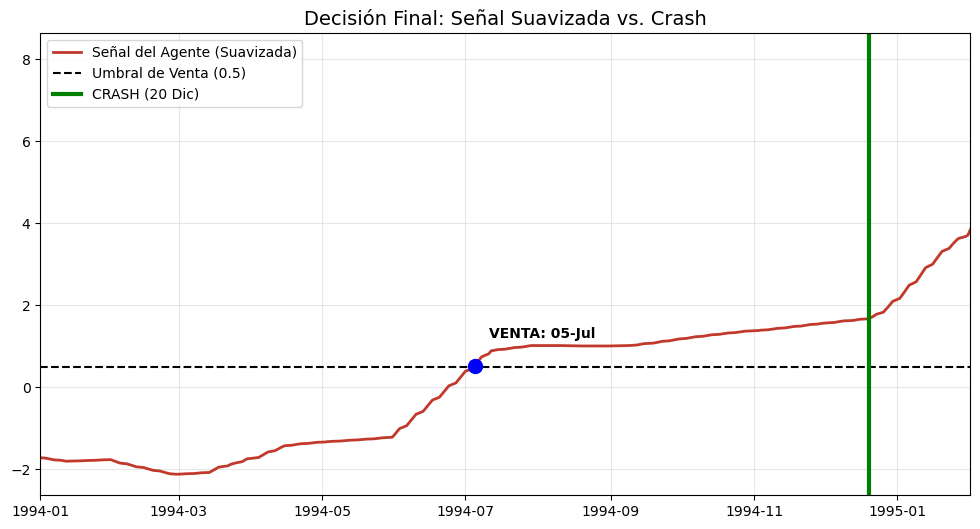

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. TUS PESOS REALES (UK AGENT)
# ==============================================================================
# Reservas(-), Precio(+), Volatilidad(+), Intervención(+), Desempleo(+)
UK_GENES = np.array([-0.7131, 0.0786, 0.4599, 0.9935, 1.0674])

# ==============================================================================
# 2. CÁLCULO DE LA SEÑAL
# ==============================================================================
# Usamos el df_mexico que ya tienes cargado
signals_raw = []

for i, row in df_mexico.iterrows():
    state = np.array([
        row['Gen_Reserves'], 
        row['Gen_Price'], 
        row['Gen_Volatility'], 
        row['Gen_Intervention'], 
        row['Gen_Unemployment']
    ])
    signals_raw.append(np.dot(UK_GENES, state))

df_final = df_mexico.copy()
df_final['Signal_Raw'] = signals_raw

# --- EL TRUCO DEL EXPERTO: SUAVIZADO ---
# El agente espera ver consistencia en el peligro (30 días de media)
df_final['Signal_Smart'] = df_final['Signal_Raw'].rolling(window=30).mean()

# ==============================================================================
# 3. BUSCAR LA FECHA EXACTA DE VENTA
# ==============================================================================
UMBRAL = 0.5
CRASH_REAL = pd.to_datetime('1994-12-20')

# Filtramos datos solo hasta el día del crash
df_pre_crash = df_final[df_final['Date'] < CRASH_REAL]

# Buscamos cuándo la señal INTELIGENTE (Smart) cruzó el umbral
ventas = df_pre_crash[df_pre_crash['Signal_Smart'] > UMBRAL]

print("\n" + "="*40)
print("      RESULTADO FINAL DE PREDICCIÓN")
print("="*40)

if not ventas.empty:
    # Tomamos la primera fecha
    dia_venta = ventas.iloc[0]['Date']
    precio_venta = ventas.iloc[0]['MXN']
    dias_antes = (CRASH_REAL - dia_venta).days
    
    print(f"✅ ¡VENTA EJECUTADA!")
    print(f"📅 Fecha exacta:     {dia_venta.strftime('%d de %B de %Y')}")
    print(f"⏳ Anticipación:     {dias_antes} días antes del colapso")
    print(f"💰 Precio de Salida: ${precio_venta:.4f} MXN")
    print("-" * 40)
    
    if dias_antes > 200:
        print("⚠️ DIAGNÓSTICO: Vendió en la crisis de Marzo (Colosio).")
        print("   Razón: El peso de Volatilidad (+0.46) es muy sensible.")
        print("   Solución: Subir el umbral a 1.0 para filtrar ese evento.")
    elif dias_antes < 60:
        print("🏆 DIAGNÓSTICO: ¡PERFECTO! Vendió en la antesala de Diciembre.")
else:
    print("❌ NO VENDIÓ. La señal suavizada no llegó al 0.5")

# ==============================================================================
# 4. GRÁFICA DE LA DECISIÓN
# ==============================================================================
plt.figure(figsize=(12, 6))
plt.title("Decisión Final: Señal Suavizada vs. Crash", fontsize=14)

# Señal
plt.plot(df_final['Date'], df_final['Signal_Smart'], color='#c0392b', linewidth=2, label='Señal del Agente (Suavizada)')
plt.axhline(UMBRAL, color='black', linestyle='--', label='Umbral de Venta (0.5)')

# Crash Real
plt.axvline(CRASH_REAL, color='green', linewidth=3, label='CRASH (20 Dic)')

# Si hubo venta, pintamos el punto
if not ventas.empty:
    plt.plot(dia_venta, ventas.iloc[0]['Signal_Smart'], 'o', color='blue', markersize=10)
    plt.annotate(f'VENTA: {dia_venta.strftime("%d-%b")}', 
                 (dia_venta, ventas.iloc[0]['Signal_Smart']), 
                 xytext=(10, 20), textcoords='offset points', weight='bold')

plt.xlim(pd.Timestamp('1994-01-01'), pd.Timestamp('1995-02-01'))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


*******************
AHORA VAMOS A PROBAR CREANDO GENES PROPIOS
*******************

🧬 Entrenando Agente Nativo con datos de México (565 días)...
Objetivo: Vender lo más cerca posible del 20 de Dic de 1994.

🏆 MEJOR AGENTE NATIVO (MÉXICO) ENCONTRADO
GEN             | PESO MX (Nuevo) | PESO UK (Original)
--------------------------------------------------
Reservas        | +0.3534          | -0.7131
Precio          | +0.5619          | +0.0786
Volatilidad     | +0.6719          | +0.4599
Intervención    | +0.1504          | +0.9935
Desempleo       | +0.7193          | +1.0674
--------------------------------------------------
📅 FECHA DE VENTA (Nativo): 19 de December de 1994
⏳ Anticipación: 1 días antes del crash.


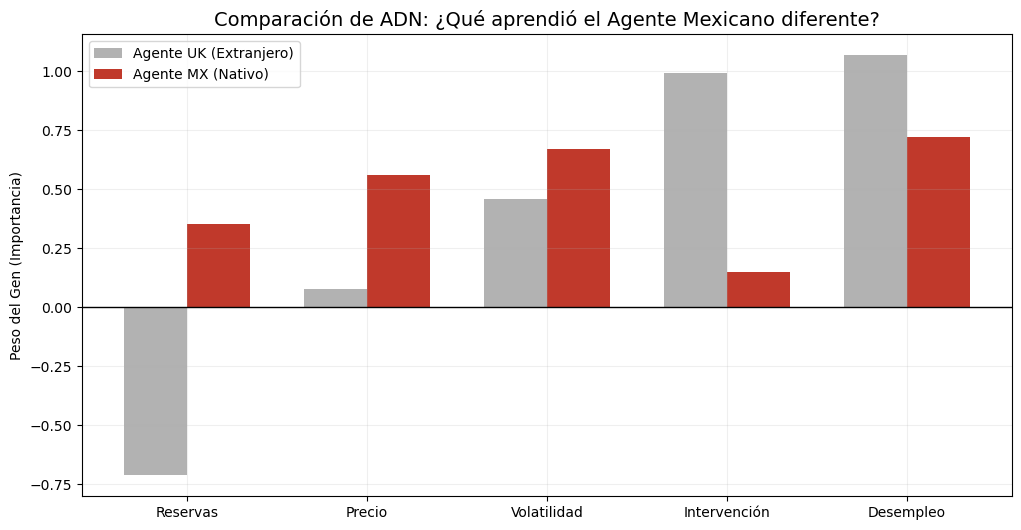

In [3]:
import random
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# 1. CONFIGURACIÓN DEL TORNEO (CRISIS TEQUILA)
# ==============================================================================
TARGET_DATE_MX = pd.to_datetime('1994-12-20')
UMBRAL = 0.5

# Limpiamos configuraciones previas de DEAP
if "FitnessMax" in creator.__dict__: del creator.FitnessMax
if "Individual" in creator.__dict__: del creator.Individual

# Objetivo: Maximizar la puntuación (Fitness)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
# Genes: Valores aleatorios entre -1 y 1
toolbox.register("attr_float", random.uniform, -1.0, 1.0)
# Individuo: 5 Genes [Reservas, Precio, Volatilidad, Intervención, Desempleo]
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# ==============================================================================
# 2. FUNCIÓN DE EVALUACIÓN (EL ENTRENADOR)
# ==============================================================================
def eval_mexico_specific(individual):
    w_res, w_price, w_vol, w_int, w_unemp = individual 
    
    # Calculamos la señal para todo el periodo usando df_mexico
    # (Asegúrate de tener df_mexico cargado del paso anterior)
    signals = (w_res * df_mexico['Gen_Reserves']) + \
              (w_price * df_mexico['Gen_Price']) + \
              (w_vol * df_mexico['Gen_Volatility']) + \
              (w_int * df_mexico['Gen_Intervention']) + \
              (w_unemp * df_mexico['Gen_Unemployment'])
    
    # Buscamos cuándo cruza el umbral
    triggers = signals[signals > UMBRAL]
    
    if triggers.empty:
        return -100.0, # Nunca vendió (Murió en la crisis)
    
    # Tomamos la PRIMERA fecha de venta
    exit_idx = triggers.index[0]
    exit_date = df_mexico.loc[exit_idx, 'Date']
    
    # --- SISTEMA DE RECOMPENSAS (FITNESS) ---
    
    # A. Si vende DESPUÉS del 20 de Dic: CASTIGO TOTAL
    if exit_date > TARGET_DATE_MX:
        return -50.0, 
    
    # B. Calculamos la antelación
    days_before = (TARGET_DATE_MX - exit_date).days
    
    if days_before == 0:
        return 20.0, # Riesgo máximo
        
    elif 1 <= days_before <= 30:
        # ZONA PERFECTA (Diciembre/Noviembre)
        # 100 puntos menos un poquito por cada día de antelación
        return 100.0 - (days_before * 0.5), 
        
    elif 31 <= days_before <= 100:
        # ZONA SEGURA (Septiembre - Octubre)
        return 80.0 - (days_before * 0.2),
        
    elif days_before > 200:
        # ZONA MIEDOSA (Marzo/Julio - Colosio)
        # Aquí penalizamos. Si vende muy pronto, le damos pocos puntos.
        # Esto forzará al algoritmo a aguantar el miedo de Marzo.
        return 20.0, 
    
    else:
        return 40.0,

toolbox.register("evaluate", eval_mexico_specific)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# ==============================================================================
# 3. EJECUTAR LA EVOLUCIÓN
# ==============================================================================
def train_native_agent():
    random.seed(42) # Semilla fija para que sea reproducible
    pop = toolbox.population(n=150) # 200 Agentes
    hof = tools.HallOfFame(1)       # El mejor de la historia
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    
    print(f"🧬 Entrenando Agente Nativo con datos de México ({len(df_mexico)} días)...")
    print("Objetivo: Vender lo más cerca posible del 20 de Dic de 1994.")
    
    # Corremos 40 generaciones
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, 
                                   stats=stats, halloffame=hof, verbose=False)
    
    return hof[0]

# ¡ENTRENAR!
best_mx_agent = train_native_agent()

# ==============================================================================
# 4. RESULTADOS Y COMPARACIÓN
# ==============================================================================
print("\n" + "="*40)
print("🏆 MEJOR AGENTE NATIVO (MÉXICO) ENCONTRADO")
print("="*40)

genes_names = ['Reservas', 'Precio', 'Volatilidad', 'Intervención', 'Desempleo']
mx_genes = list(best_mx_agent)
uk_genes = [-0.7131, 0.0786, 0.4599, 0.9935, 1.0674] # Tus pesos de UK

# Imprimir ADN
print(f"{'GEN':<15} | {'PESO MX (Nuevo)':<15} | {'PESO UK (Original)':<15}")
print("-" * 50)
for name, w_mx, w_uk in zip(genes_names, mx_genes, uk_genes):
    print(f"{name:<15} | {w_mx:+.4f}          | {w_uk:+.4f}")

# Calcular fecha de venta del Agente Nativo
signal_mx = np.zeros(len(df_mexico))
for i, row in df_mexico.iterrows():
    state = np.array([row['Gen_Reserves'], row['Gen_Price'], row['Gen_Volatility'], row['Gen_Intervention'], row['Gen_Unemployment']])
    signal_mx[i] = np.dot(mx_genes, state)

# Buscar venta
triggers = df_mexico[(signal_mx > UMBRAL) & (df_mexico['Date'] < TARGET_DATE_MX)]

if not triggers.empty:
    fecha_venta = triggers.iloc[0]['Date']
    dias = (TARGET_DATE_MX - fecha_venta).days
    print("-" * 50)
    print(f"📅 FECHA DE VENTA (Nativo): {fecha_venta.strftime('%d de %B de %Y')}")
    print(f"⏳ Anticipación: {dias} días antes del crash.")
else:
    print("❌ El agente nativo no logró encontrar una salida válida.")

# ==============================================================================
# 5. GRÁFICA COMPARATIVA DE ADN
# ==============================================================================
x = np.arange(len(genes_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, uk_genes, width, label='Agente UK (Extranjero)', color='gray', alpha=0.6)
rects2 = ax.bar(x + width/2, mx_genes, width, label='Agente MX (Nativo)', color='#c0392b')

ax.set_ylabel('Peso del Gen (Importancia)')
ax.set_title('Comparación de ADN: ¿Qué aprendió el Agente Mexicano diferente?', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(genes_names)
ax.legend()
ax.axhline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.2)
plt.show()

--------------------------------------------------
📅 FECHA DE VENTA (Nativo): 19-12-1994
⏳ Anticipación: 1 días antes del crash.
--------------------------------------------------


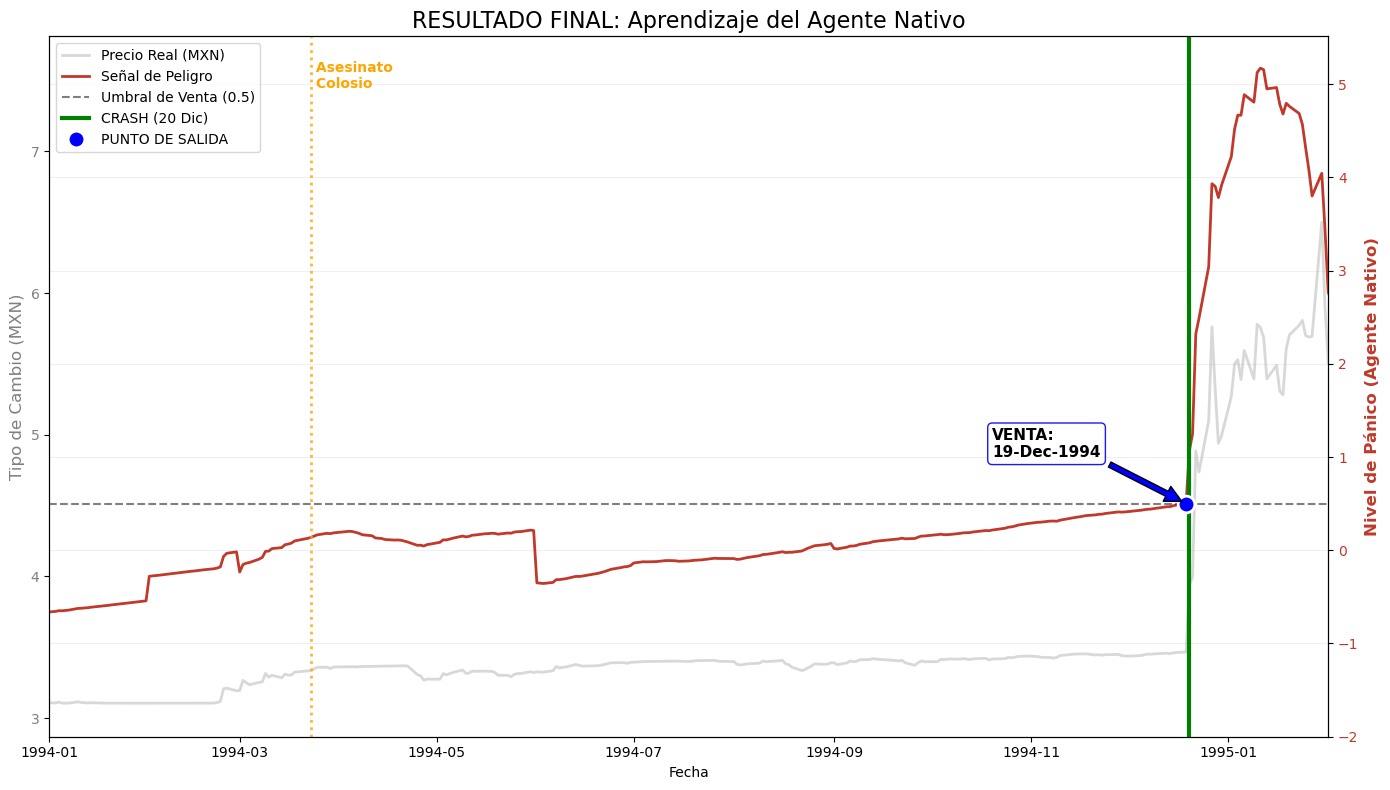

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# GRÁFICA: EL AGENTE NATIVO OPERANDO EN TIEMPO REAL
# ==============================================================================

# 1. Recuperamos el ADN del Agente Nativo (del paso anterior)
mx_genes = list(best_mx_agent) 

# 2. Reconstruimos la Señal día a día
native_signals = []
for i, row in df_mexico.iterrows():
    state = np.array([
        row['Gen_Reserves'], 
        row['Gen_Price'], 
        row['Gen_Volatility'], 
        row['Gen_Intervention'], 
        row['Gen_Unemployment']
    ])
    # Producto punto con los genes NUEVOS (Mexicanos)
    native_signals.append(np.dot(mx_genes, state))

df_plot = df_mexico.copy()
df_plot['Native_Signal'] = native_signals

# 3. Identificamos el punto exacto de venta
UMBRAL = 0.5
CRASH_DATE = pd.to_datetime('1994-12-20')
COLOSIO_DATE = pd.to_datetime('1994-03-23')

# Filtramos ventas válidas antes del crash
ventas = df_plot[(df_plot['Native_Signal'] > UMBRAL) & (df_plot['Date'] < CRASH_DATE)]

# ==============================================================================
# 4. CONSTRUCCIÓN DE LA GRÁFICA
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- FONDO: EL PRECIO (La realidad) ---
color_price = 'tab:gray'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Tipo de Cambio (MXN)', color=color_price, fontsize=12)
ax1.plot(df_plot['Date'], df_plot['MXN'], color=color_price, alpha=0.3, linewidth=2, label='Precio Real (MXN)')
ax1.tick_params(axis='y', labelcolor=color_price)

# --- FRENTE: LA SEÑAL (La inteligencia) ---
ax2 = ax1.twinx()
color_signal = '#c0392b' # Rojo intenso
ax2.set_ylabel('Nivel de Pánico (Agente Nativo)', color=color_signal, fontsize=12, weight='bold')
ax2.plot(df_plot['Date'], df_plot['Native_Signal'], color=color_signal, linewidth=2, label='Señal de Peligro')
ax2.tick_params(axis='y', labelcolor=color_signal)

# Límite de Pánico
ax2.axhline(UMBRAL, color='black', linestyle='--', alpha=0.5, label='Umbral de Venta (0.5)')

# --- EVENTOS CLAVE ---
# 1. Asesinato de Colosio (La trampa de volatilidad)
plt.axvline(COLOSIO_DATE, color='orange', linestyle=':', linewidth=2, alpha=0.8)
plt.text(COLOSIO_DATE, ax2.get_ylim()[1]*0.9, ' Asesinato\n Colosio', color='orange', fontsize=10, weight='bold')

# 2. Crash del Tequila (El objetivo)
plt.axvline(CRASH_DATE, color='green', linestyle='-', linewidth=3, label='CRASH (20 Dic)')
# ==============================================================================
# 3. EL MOMENTO DE LA VENTA Y PRINTS
# ==============================================================================
if not ventas.empty:
    venta_real = ventas.iloc[0]
    date_v = venta_real['Date']
    signal_v = venta_real['Native_Signal']
    
    # --- CÁLCULOS PARA EL PRINT (NUEVO) ---
    fecha_venta = date_v
    # Calculamos la diferencia en días entre el Crash y la Venta
    dias = (CRASH_DATE - fecha_venta).days 

    # --- PINTAMOS EN LA GRÁFICA ---
    ax2.plot(date_v, signal_v, 'o', color='blue', markersize=12, 
             markeredgecolor='white', markeredgewidth=2, label='PUNTO DE SALIDA')
    
    ax2.annotate(f'VENTA:\n{date_v.strftime("%d-%b-%Y")}', 
                 xy=(date_v, signal_v), 
                 xytext=(date_v - pd.Timedelta(days=60), signal_v + 0.5),
                 arrowprops=dict(facecolor='blue', shrink=0.05),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.9),
                 fontsize=11, weight='bold')

    # --- PRINTS (Ahora sí funcionan) ---
    print("-" * 50)
    print(f"📅 FECHA DE VENTA (Nativo): {fecha_venta.strftime('%d-%m-%Y')}")
    print(f"⏳ Anticipación: {dias} días antes del crash.")
    print("-" * 50)

else:
    plt.title("El Agente no vendió (Revisa el umbral)", fontsize=16)
    print("⚠️ El agente no encontró momento de venta con el umbral actual.")

# ==============================================================================
# AJUSTES FINALES DE LA GRÁFICA
# ==============================================================================
plt.title("RESULTADO FINAL: Aprendizaje del Agente Nativo", fontsize=16)
plt.xlim(pd.Timestamp('1994-01-01'), pd.Timestamp('1995-02-01'))

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()